# Setup

In [3]:
import os
import pickle
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error as mse

import matplotlib.pyplot as plt
import seaborn as sns

# Start with the default (light) style
plt.style.use('default')

# Now update the rcParams to match your desired white-background style
plt.rcParams.update({
    'axes.facecolor': 'white',         # axes background
    'figure.facecolor': 'white',       # figure background
    'axes.edgecolor': 'black',         # border of plot
    'axes.labelcolor': 'black',        # axis labels
    'xtick.color': 'black',
    'ytick.color': 'black',
    'grid.color': 'black',             # grid lines color
    'grid.linewidth': 0.5,
    'grid.alpha': 0.2,                 # faint grid
    'font.size': 12,
    'legend.frameon': True,
    'lines.linewidth': 2,
    'figure.dpi': 150
})

def variable_df(dataframe, variable, model, datetime_component, norm=False, quantiles=[0.1, 0.25, 0.5, 0.75, 0.9]):
    # Step 1: Round and convert

    if variable == 'cost' and datetime_component == 'month':
        dataframe = dataframe.resample('D').sum()

    df_rounded = dataframe.round(4).astype('float32')

    # Step 2: Slice by variable
    df_var = df_rounded.xs(variable, level='variable', axis=1)

    # Step 3: Normalize if needed
    if norm:
        df_var = df_var / (df_var.iloc[0] * 2)

    # Step 4: Slice by model
    df_model = df_var.xs(model, level='dictionary', axis=1)

    # Step 5: Create datetime component column (e.g., hour)
    df_model = df_model.copy()
    df_model[datetime_component] = getattr(df_model.index, datetime_component)

    # Step 6: Melt to long format (one value per row)
    df_melted = df_model.melt(id_vars=datetime_component, var_name='building', value_name='value')

    # Step 7: Group by datetime component (e.g., hour) and compute quantiles across buildings
    df_quantiles = df_melted.groupby(datetime_component)['value'].quantile(quantiles).unstack()
    df_quantiles.columns = [f'Q{int(q*100):02d}' for q in quantiles]

    return df_quantiles

def plot_scatter_plot(mse_data, cost_data):
    # Create a figure
    plt.figure(figsize=(8, 5), dpi=180)

    # Scatter plot for each model
    for model in mse_data.keys():
        # Get the MSE and cost values for each building
        mse_values = mse_data[model]
        cost_values = cost_data[model]

        # Scatter plot
        plt.scatter(mse_values, cost_values, label=model, alpha=0.7)

    # Set labels and title
    plt.xlabel("RMSE", fontsize=12)
    plt.ylabel("Cost", fontsize=12)
    plt.title("Scatter Plot of Cost vs. RMSE", fontsize=18, fontweight="bold")

    # Add a legend
    plt.legend(title="Models", loc="lower left", fontsize=14)

    # Show grid for better visibility
    plt.grid(True, linestyle="--", alpha=0.6)

    # Show the plot
    plt.tight_layout()
    plt.show()

def hourly_quantile_plot(stats, size=(14, 6), title='Hourly Distribution Across Buildings and Days'):
    plt.figure(figsize=size)

    # Plot median
    plt.plot(stats.index, stats['Q50'], label='Median (Q50)', color='blue')

    # Fill interquartile range (Q25–Q75)
    if 'Q25' in stats.columns and 'Q75' in stats.columns:
        plt.fill_between(
            stats.index,
            stats['Q25'],
            stats['Q75'],
            color='blue',
            alpha=0.25,
            label='Interquartile Range (Q25–Q75)'
        )

    # Fill outer range (Q10–Q90)
    if 'Q10' in stats.columns and 'Q90' in stats.columns:
        plt.fill_between(
            stats.index,
            stats['Q10'],
            stats['Q90'],
            color='blue',
            alpha=0.15,
            label='10th–90th Percentile Range'
        )

    plt.xticks(range(len(stats)))
    plt.xlabel('Hour of Day')
    plt.ylabel('Value')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def compare_hourly_quantile_plots(stats_list, rowtitles, columns=3, rows=1, titles=None, x_axis='Hour of the day', size=(18, 5)):
    n = len(stats_list)
    if titles is None:
        titles = [f"Plot {i+1}" for i in range(n)]

    # Step 1: Find global min and max across all stats
    global_min = min(df[[col for col in df.columns if col.startswith('Q')]].min().min() for df in stats_list)
    global_max = max(df[[col for col in df.columns if col.startswith('Q')]].max().max() for df in stats_list)

    # Step 2: Create subplots (note: rows first!)
    fig, axes = plt.subplots(rows, columns, figsize=size, sharey=True)

    # Flatten axes for easy iteration
    axes = axes.flatten() if isinstance(axes, (list, np.ndarray)) else [axes]

    for row in range(rows):
            # Compute y position (between 0 and 1, from bottom to top)
            y_pos = 1 - (row + 0.5) / rows
            fig.text(0, y_pos, rowtitles[row], ha='center', va='center',rotation=90, fontsize=14, fontweight='bold')

    # Step 3: Plot each
    for i, (ax, stats, title) in enumerate(zip(axes, stats_list, titles)):
        line_color = '#66B2FF'
        fill_iqr_color = '#66B2FF'
        fill_outer_color = '#66B2FF'

        ax.plot(stats.index, stats['Q50'], label='Median (Q50)', color=line_color)

        if 'Q25' in stats.columns and 'Q75' in stats.columns:
            ax.fill_between(
                stats.index, stats['Q25'], stats['Q75'],
                color=fill_iqr_color, alpha=0.4,
                label='IQR (Q25–Q75)' if i == 0 else None
            )

        if 'Q10' in stats.columns and 'Q90' in stats.columns:
            ax.fill_between(
                stats.index, stats['Q10'], stats['Q90'],
                color=fill_outer_color, alpha=0.2,
                label='P10–P90' if i == 0 else None
            )

        ax.axhline(y=0, color='gray', linestyle='--', linewidth=1)

        ax.set_title(title)
        ax.set_xlabel(x_axis)
        ax.grid(True)
        ax.set_xticks(range(0, len(stats), 2))
        ax.set_ylim(global_min, global_max * 1.1)


    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0), ncol=3)

    fig.suptitle('Averaged hourly PV forecasts per model', fontsize=18, fontweight='bold')
    plt.tight_layout()
    plt.show()

def hourly_combo_confidence_plot(stats1, stats2, label1='Dataset 1', label2='Dataset 2', color1='blue', color2='green'):

    # Plotting
    plt.figure(figsize=(14, 6))

    # Plot mean lines
    plt.plot(stats1.index, stats1['mean'], label=f'{label1} Mean', color=color1)
    plt.plot(stats2.index, stats2['mean'], label=f'{label2} Mean', color=color2)

    # Plot confidence intervals
    for i, alpha in zip([1, 2], [0.3, 0.15]):
        plt.fill_between(
            stats1.index,
            stats1['mean'] - i * stats1['std'],
            stats1['mean'] + i * stats1['std'],
            color=color1,
            alpha=alpha,
            label=f'{label1} ±{i} Std Dev' if i == 1 else None  # Avoid repeating in legend
        )
        plt.fill_between(
            stats2.index,
            stats2['mean'] - i * stats2['std'],
            stats2['mean'] + i * stats2['std'],
            color=color2,
            alpha=alpha,
            label=f'{label2} ±{i} Std Dev' if i == 1 else None
        )

    plt.xticks(range(len(stats1)))
    plt.ylim(min(min(stats1['mean'] - 3 * stats1['std']),min(stats2['mean'] - 3 * stats2['std'])), max(max(stats1['mean'] + 3 * stats1['std']),max(stats2['mean'] + 3 * stats2['std'])))
    plt.xlabel('Hour of Day')
    plt.ylabel('Value')
    plt.title('Hourly Average with Confidence Intervals for Two Datasets')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [4]:
noise_levels = [0, 0.25, 0.5, 1, 1.75, 2.75, 4]

In [6]:
df_long_list = []
for noise in noise_levels:
    df_long_list.append(pd.read_pickle("../results/all_data_long_" + str(noise) + "_noise.pkl").set_index('datetime'))

In [8]:
buildings = list(df_long_list[0].building.unique())
models = list(df_long_list[0].dictionary.unique())

In [9]:
noise_mse_list = []
noise_cost_list = []

for df_long in df_long_list:
    model_mse = {model: [] for model in models}
    model_costs = {model: [] for model in models}

    for model in models:
        for building in buildings:
            model_mse[model].append(mse(df_long[(df_long['building'] == building) & (df_long['dictionary'] == 'perfect') & (df_long['variable'] == 'pv')].value /               # True values divided by
                                        max(df_long[(df_long['building'] == building) & (df_long['dictionary'] == 'perfect') & (df_long['variable'] == 'pv')].value),           # Maximum of true values
                                        df_long[(df_long['building'] == building) & (df_long['dictionary'] == model) & (df_long['variable'] == 'pv')].value /                   # Predicted values divided by
                                        max(df_long[(df_long['building'] == building) & (df_long['dictionary'] == 'perfect') & (df_long['variable'] == 'pv')].value),           # Maximum of true values
                                        squared=False))                                                                                                                         # Root of the MSE

            model_costs[model].append(sum(df_long[(df_long['building'] == building) & (df_long['dictionary'] == model) & (df_long['variable'] == 'cost')].value)) # profit for injection

    noise_mse_list.append(model_mse)
    noise_cost_list.append(model_costs)

In [13]:
noise_mse_dict = dict(zip(noise_levels, noise_mse_list))
noise_cost_dict = dict(zip(noise_levels, noise_cost_list))

In [25]:
average_mse_dict = noise_mse_dict.copy()
average_cost_dict = noise_cost_dict.copy()

for noise in noise_mse_dict.keys():
    for model in noise_mse_dict[noise].keys():
        average_mse_dict[noise][model] = np.average(noise_mse_dict[noise][model])
        average_cost_dict[noise][model] = np.average(noise_cost_dict[noise][model])

In [37]:
average_mse_df = pd.DataFrame({k: list(v.values()) for k, v in average_mse_dict.items()}, index=average_mse_dict[0].keys())
average_cost_df = pd.DataFrame({k: list(v.values()) for k, v in average_cost_dict.items()}, index=average_cost_dict[0].keys())

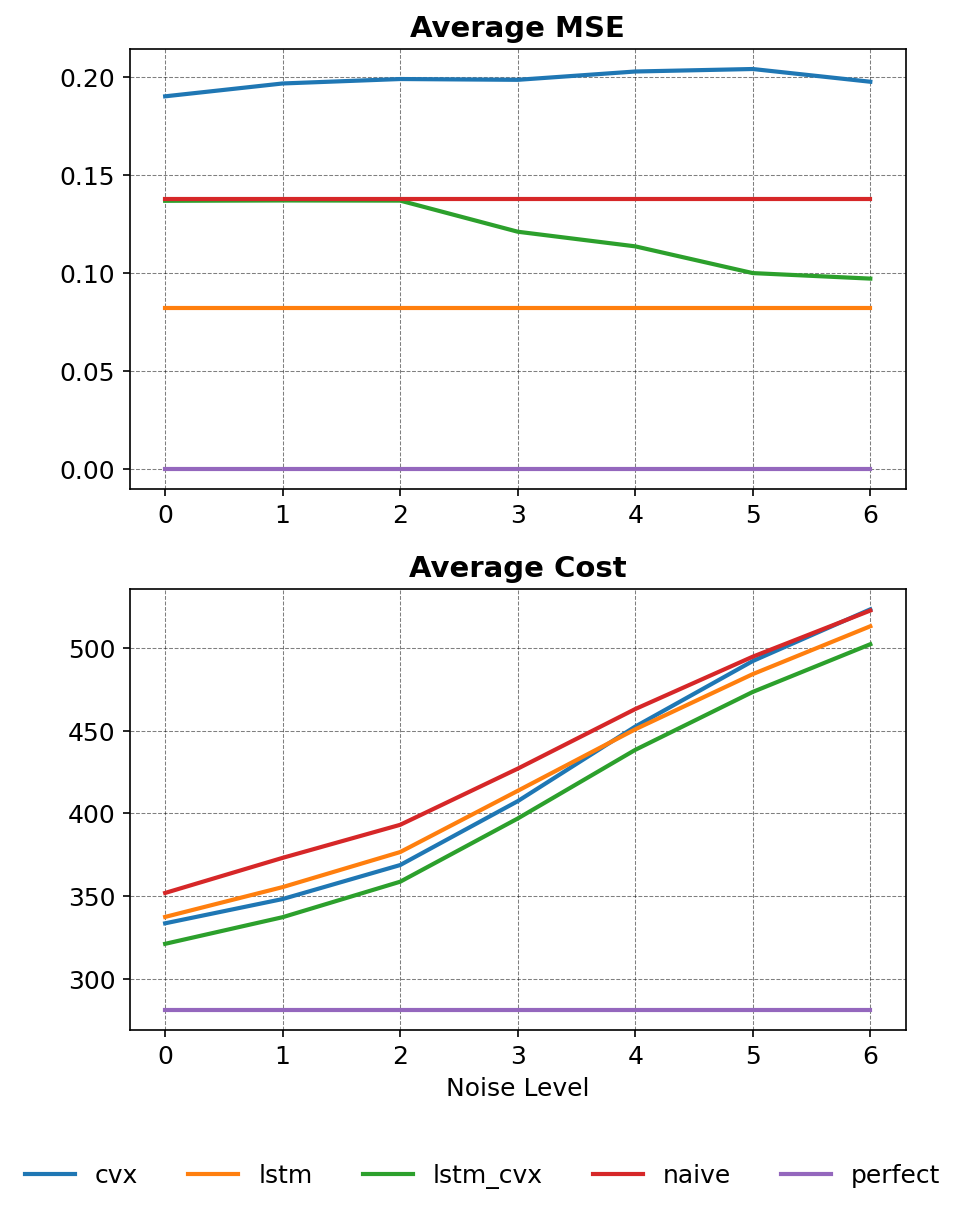

In [57]:
fig, axes = plt.subplots(2, 1, figsize=(6, 8), sharey=False)

# Plot MSE
axes[0].plot(average_mse_df.transpose().values, linewidth=2)
axes[0].set_title('Average MSE', fontweight='bold', fontsize=14)
axes[0].grid(True, linestyle='--', alpha=0.5)

# Plot Cost
axes[1].plot(average_cost_df.transpose().values, linewidth=2)
axes[1].set_title('Average Cost', fontweight='bold', fontsize=14)
axes[1].set_xlabel('Noise Level')  # Optional: adjust label if it's something else
axes[1].grid(True, linestyle='--', alpha=0.5)

# Shared legend below both plots
fig.legend(
    labels=average_mse_df.index,  # assumes both dfs have same index
    loc='lower center',
    ncol=len(average_mse_df.index),
    bbox_to_anchor=(0.5, -0.02),
    frameon=False
)

# Adjust layout to make room for the legend
plt.tight_layout(rect=[0, 0.05, 1, 1])

plt.show()

In [108]:
data_folder = "../data/load_fcsts/"  # relative path

building_ids = [f"building_{i}" for i in range(27)]
to_remove = ['building_2','building_6','building_7','building_14','building_15','building_18','building_19']
for item in to_remove:
    if item in building_ids:
        building_ids.remove(item)
noise_levels = [0.25, 0.5, 1, 1.75, 2.75, 4]

dataframes = {}

for noise in noise_levels:
    df_dict = {}
    for building in building_ids:
        filename = f"{building}_{noise}_noise_forecast.npy"
        filepath = os.path.join(data_folder, filename)

        if os.path.exists(filepath):
            df_dict[building] = np.load(filepath)
        else:
            print(f"Missing file: {filename}")
            df_dict[building] = np.nan

    dataframes[noise] = pd.DataFrame(df_dict)

In [109]:
dataframes[0.25]

,building_0,building_1,building_3,building_4,building_5,building_8,building_9,building_10,building_11,building_12,building_13,building_16,building_17,building_20,building_21,building_22,building_23,building_24,building_25,building_26
0,1.098527,0.676347,0.067172,0.334224,0.594946,0.100774,0.117578,0.367176,0.259230,0.097214,0.868908,0.177829,0.148637,0.234311,0.359159,1.493345,0.115321,0.347706,0.525783,0.418161
1,0.527131,0.378126,0.102980,0.602509,0.203196,0.110898,0.201102,0.312624,0.133530,0.091561,0.305894,0.150887,0.107023,0.176654,0.324567,0.502973,0.133932,0.185411,0.325301,0.222137
2,0.395497,0.384917,0.070172,0.208414,0.143621,0.088006,0.425306,0.192359,0.110766,0.108971,0.143233,0.129408,0.107687,0.220252,0.478923,0.277656,0.138958,0.309053,0.357829,0.185775
3,0.436793,0.330885,0.117320,0.164598,0.223911,0.142117,0.583701,0.119878,0.160719,0.205403,0.085070,0.192550,0.156489,0.386649,0.436497,0.387837,0.169971,0.250132,0.417470,0.143695
4,0.685150,0.281932,0.333959,0.109767,0.422406,0.378745,0.179036,0.134048,0.369319,0.537568,0.161296,0.367298,0.372167,0.605065,0.773642,0.500262,0.212446,0.326633,0.381292,0.151675
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27043,0.681665,0.571202,0.115966,0.226834,0.299024,1.290605,0.314322,0.107828,0.925960,0.140845,0.529757,0.226297,0.276766,0.124341,0.188525,0.320937,0.319947,1.247930,0.073513,0.317459
27044,0.456654,0.512953,0.130388,0.341139,0.257029,0.406715,0.107241,0.135085,0.256373,0.152584,0.500625,0.339373,0.361634,0.348441,0.247386,0.334606,0.942151,0.234601,0.100098,0.186181
27045,0.322786,0.717920,0.129949,0.250338,0.454806,0.186065,0.233893,0.238906,0.090897,0.149117,1.729260,0.280973,0.287355,0.511905,0.215176,0.280277,0.417895,0.471935,0.092443,0.232384
27046,0.319105,0.889602,0.140475,0.282030,0.355939,0.124677,0.323033,0.612414,0.197740,0.183560,2.533282,0.230951,0.563712,0.362333,0.216759,0.267180,0.479440,0.198216,0.114083,0.283785


In [94]:
import src.data.dataprep as prep
real_dataframes = []
for building in building_ids:
    try:
        real_dataframes.append(prep.dutch_data('../data/Dutchdata_clean/' + str(building) + '.parquet', 'h', price='Realistic'))
    except:
        continue

In [95]:
len(real_dataframes)

20

In [125]:
noise_building_mse = []

for noise in noise_levels:
    i = 0
    noise_mse = []
    for building in dataframes[noise].columns.values:
        noise_mse.append(mse(real_dataframes[i]['load'], dataframes[noise][building],squared=False))
        i+=1
    noise_building_mse.append(noise_mse)

noise_mse_df = pd.DataFrame(noise_building_mse)

In [126]:
noise_mse_df

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,0.226869,0.208935,0.170830,0.189599,0.219889,0.171322,0.208029,0.221666,0.190232,0.125136,0.247616,0.187095,0.148963,0.160559,0.153586,0.221076,0.192328,0.178368,0.232761,0.233018
1,0.391492,0.347558,0.282675,0.310580,0.379067,0.261331,0.337907,0.370644,0.307105,0.212348,0.397880,0.316344,0.239319,0.258735,0.265064,0.365994,0.308464,0.298232,0.376324,0.375330
2,0.574624,0.504938,0.404841,0.453326,0.547659,0.372378,0.496141,0.538847,0.427112,0.313373,0.578064,0.519600,0.352616,0.366335,0.398245,0.545409,0.443918,0.437691,0.547038,0.560537
3,0.715871,0.636382,0.508047,0.571152,0.685934,0.467228,0.625191,0.673722,0.520170,0.390541,0.704210,0.702170,0.435615,0.449097,0.506318,0.680596,0.542219,0.554395,0.687902,0.704906
4,0.825296,0.765979,0.606831,0.690045,0.819175,0.569221,0.734179,0.802597,0.596781,0.452396,0.817986,0.836217,0.518940,0.531949,0.602506,0.817711,0.648284,0.664403,0.808898,0.845002
5,0.927943,0.886044,0.698681,0.804805,0.926852,0.662693,0.842576,0.922754,0.675592,0.503605,0.926067,0.951125,0.601442,0.618230,0.695691,0.939700,0.744580,0.768736,0.954836,1.007018


In [129]:
noise_mse_df.mean(axis=1)

0    0.194394
1    0.320120
2    0.469134
3    0.588083
4    0.697720
5    0.802949
dtype: float64